In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

2.1 Data Preprocessing & Cleaning 

In [ ]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from ucimlrepo import fetch_ucirepo 

# fetch dataset (Cleveland Heart Disease subset)
heart_disease = fetch_ucirepo(id=45)

# Features and target
X = heart_disease.data.features
y = heart_disease.data.targets

# Combine into one DataFrame (features + target)
df = X.copy()
df["target"] = y

#  Preview first 5 rows
print(df.head())

# Summary statistics (numeric columns)
print(df.describe())

# Info about columns & types
print(df.info())

#  Value counts of the target
print(df["target"].value_counts())


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  target  
0  0.0   6.0       0  
1  3.0   3.0       2  
2  2.0   7.0       1  
3  0.0   3.0       0  
4  0.0   3.0       0  
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    3.158416  131.689769  246.693069    0.148515   
std      9.038662    0.467299    0.960126   17.599748   51.776918    0.356198   
min     29.000000    0.000000    1.000000   94.0000

In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


Handling missing values

In [ ]:
df.isnull()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,False,False,False,False,False,False,False,False,False,False,False,False,False,False
299,False,False,False,False,False,False,False,False,False,False,False,False,False,False
300,False,False,False,False,False,False,False,False,False,False,False,False,False,False
301,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
print(df.isnull().sum())       # count NaN per column
print(df.isnull().sum().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64
6


In [ ]:
print(df.notnull().sum())       # count NaN per column
print(df.notnull().sum().sum())

age         303
sex         303
cp          303
trestbps    303
chol        303
fbs         303
restecg     303
thalach     303
exang       303
oldpeak     303
slope       303
ca          299
thal        301
target      303
dtype: int64
4236


In [ ]:
df.dropna()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57,0,4,140,241,0,0,123,1,0.2,2,0.0,7.0,1
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3


In [ ]:
print(df.isna().sum())       # count NaN per column
print(df.isna().sum().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64
6


Encoding

In [ ]:
# Define categorical columns
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

# One-hot encode categorical columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(X_encoded.head())
print("Shape before:", X.shape)
print("Shape after:", X_encoded.shape)

   age  trestbps  chol  thalach  oldpeak  sex_1   cp_2   cp_3   cp_4  fbs_1  \
0   63       145   233      150      2.3   True  False  False  False   True   
1   67       160   286      108      1.5   True  False  False   True  False   
2   67       120   229      129      2.6   True  False  False   True  False   
3   37       130   250      187      3.5   True  False   True  False  False   
4   41       130   204      172      1.4  False   True  False  False  False   

   restecg_1  restecg_2  exang_1  slope_2  slope_3  ca_1.0  ca_2.0  ca_3.0  \
0      False       True    False    False     True   False   False   False   
1      False       True     True     True    False   False   False    True   
2      False       True     True     True    False   False    True   False   
3      False      False    False    False     True   False   False   False   
4      False       True    False    False    False   False   False   False   

   thal_6.0  thal_7.0  
0      True     False  
1     Fa

Standardize numerical features

In [ ]:
from sklearn.preprocessing import StandardScaler
num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

scaler = StandardScaler()
X_encoded[num_cols] = scaler.fit_transform(X_encoded[num_cols])

print(X_encoded[num_cols].head())

        age  trestbps      chol   thalach   oldpeak
0  0.948726  0.757525 -0.264900  0.017197  1.087338
1  1.392002  1.611220  0.760415 -1.821905  0.397182
2  1.392002 -0.665300 -0.342283 -0.902354  1.346147
3 -1.932564 -0.096170  0.063974  1.637359  2.122573
4 -1.489288 -0.096170 -0.825922  0.980537  0.310912


Exploratory Data Analysis (EDA)

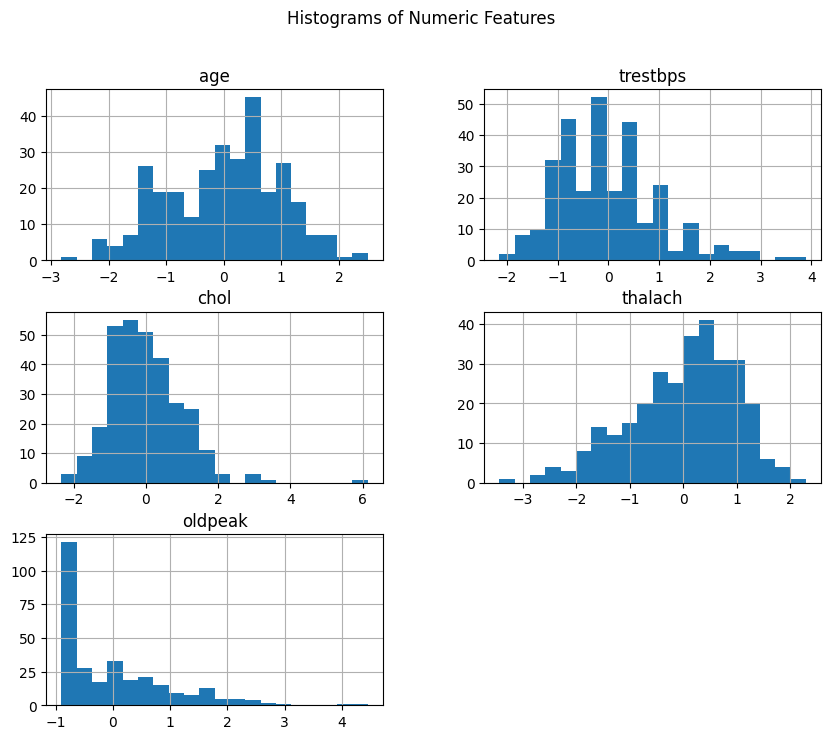

In [ ]:
X_encoded[num_cols].hist(bins=20, figsize=(10,8))
plt.suptitle("Histograms of Numeric Features")
plt.show()

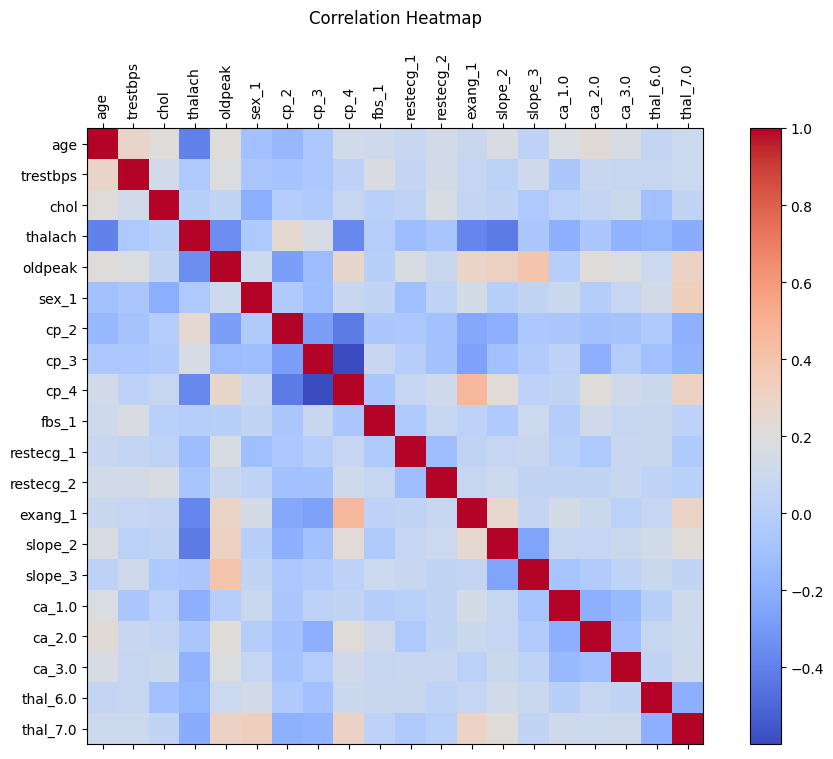

In [ ]:
corr = X_encoded.corr()

fig, ax = plt.subplots(figsize=(12, 8))
cax = ax.matshow(corr, cmap="coolwarm")
plt.colorbar(cax)

# Set ticks
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

plt.title("Correlation Heatmap", pad=20)
plt.show()

C:\Users\minoo\AppData\Local\Temp\ipykernel_8320\383870915.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[row, col_idx].boxplot(
C:\Users\minoo\AppData\Local\Temp\ipykernel_8320\383870915.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[row, col_idx].boxplot(
C:\Users\minoo\AppData\Local\Temp\ipykernel_8320\383870915.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[row, col_idx].boxplot(
C:\Users\minoo\AppData\Local\Temp\ipykernel_8320\383870915.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name

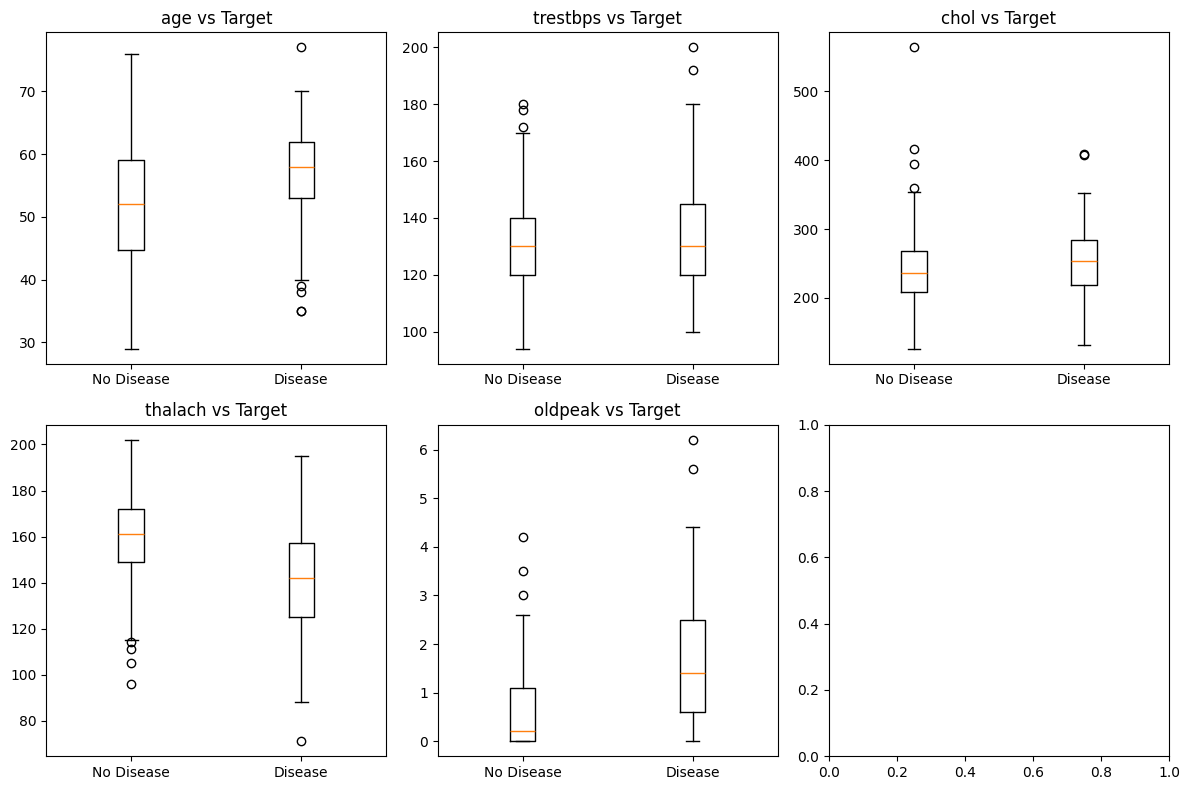

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i, col in enumerate(num_cols):
    row, col_idx = divmod(i, 3)
    axes[row, col_idx].boxplot(
        [df_clean[df_clean["target"] == 0][col], df_clean[df_clean["target"] == 1][col]],
        labels=["No Disease", "Disease"]
    )
    axes[row, col_idx].set_title(f"{col} vs Target")

plt.tight_layout()
plt.show()